In [1]:
%load_ext autoreload
%autoreload 2
import os
import glob
import wandb
import h5py
import sys
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.multiprocessing as mp

sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from train_functions import train_epochs
from build_model import resnet50_
from prediction_analysis import confusion_matrix, plot_cm
from utils import viz_dataloader, hdf5_dataset_stack, split_train_valid, list_to_dict, viz_h5_structure
from style import set_style
set_style('printing')
plt.rcParams['xtick.top'] = False
plt.rcParams['xtick.bottom'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['ytick.right'] = False

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)


printing set for seaborn


In [2]:
device = torch.device('cuda:0')

model = resnet50_(in_channels=10, n_classes=17).to(device)
outputs = model(torch.randn(2,10,256,256).to(device))
print(outputs.shape)

torch.Size([2, 17])


### stacked dataset

In [3]:
h5_file = '../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5'
with h5py.File(h5_file, 'r') as h5:
    viz_h5_structure(h5)

'Group': atom
  'Dataset': data; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': labels; Shape: (100000,); dtype: uint8
  'Dataset': magnitude_spectrum; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': phase_spectrum; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': radon; Shape: (100000, 256, 256); dtype: float32
'Group': imagenet
  'Dataset': data; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': labels; Shape: (100000,); dtype: uint8
  'Dataset': magnitude_spectrum; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': phase_spectrum; Shape: (100000, 256, 256, 3); dtype: float32
  'Dataset': radon; Shape: (100000, 256, 256); dtype: float32
'Group': noise
  'Dataset': data; Shape: (102000, 256, 256, 3); dtype: float32
  'Dataset': labels; Shape: (102000,); dtype: uint8
  'Dataset': magnitude_spectrum; Shape: (102000, 256, 256, 3); dtype: float32
  'Dataset': phase_spectrum; Shape: (102000, 256, 256, 3); dtype: float32
  'Dataset': radon; Shape

In [ ]:
# imagenet
imagenet_ds = hdf5_dataset_stack(h5_file, folder='imagenet', transform=transforms.ToTensor(), data_keys=['data', 'magnitude_spectrum', 'phase_spectrum', 'radon'], label_key='labels')
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True, stacked=True)

valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True, stacked=True)

# atom
atom_ds = hdf5_dataset_stack(h5_file, folder='atom', transform=transforms.ToTensor(),
                       data_keys=['data', 'magnitude_spectrum', 'phase_spectrum', 'radon'], label_key='labels')
atom_dl = DataLoader(atom_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv', show_colorbar=True, stacked=True)

# noise
noise_ds = hdf5_dataset_stack(h5_file, folder='noise', transform=transforms.ToTensor(),
                       data_keys=['data', 'magnitude_spectrum', 'phase_spectrum', 'radon'], label_key='labels')
noise_dl = DataLoader(noise_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv', show_colorbar=True, stacked=True)

## Train

In [8]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_radon_stacked'

wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [9]:
lr = 1e-3
start = 0
epochs = 50
device = torch.device('cuda:0')

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [07:01<00:00,  3.15s/it]


Training: Loss: 3.0379, Accuracy: 6.1225%, Time: 7.0321mins


100%|██████████| 34/34 [01:31<00:00,  2.70s/it]


...

Training: Loss: 0.0045, Accuracy: 99.9888%, Time: 2.5742mins


100%|██████████| 34/34 [00:26<00:00,  1.27it/s]


Validation : Loss : 0.8955, Accuracy: 80.8450%, Time: 0.45mins


100%|██████████| 167/167 [02:00<00:00,  1.39it/s]


Validation : Loss : 6.2145, Accuracy: 8.2770%, Time: 2.00mins


## Analysis

### generate confusion matrix

In [11]:
model = torch.load('../../../saved_models/preprocess-fft_radon_stacked/epoch-50.pt')

NAME = 'preprocess-fft_radon_stacked'
device = torch.device('cuda:0')                

In [12]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-train_cm.npy', cm)

cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-valid_cm.npy', cm)

cm = confusion_matrix(model, atom_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-cv_atom_cm.npy', cm)

cm = confusion_matrix(model, noise_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/{NAME}-cv_noise_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [01:55<00:00,  1.16it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4738.0,4752.0,4717.0,4721.0,4686.0,4767.0,4698.0,4611.0,4717.0,4723.0,4582.0,4734.0,4719.0,4655.0,4771.0,4622.0,4787.0


Accuracy for these batches: 100.0%


...

Accuracy for these batches: 8.277%


100%|██████████| 170/170 [02:50<00:00,  1.00s/it]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 31.877450980392158%


### visualize confusion matrix

['../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-train_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-valid_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-cv_atom_cm.npy', '../../../saved_results/data_preprocessing/FFT_Radon_transform/preprocess-fft_phase_spectrum-cv_noise_cm.npy']
Summary_cm-preprocess_fft_phase_spectrum


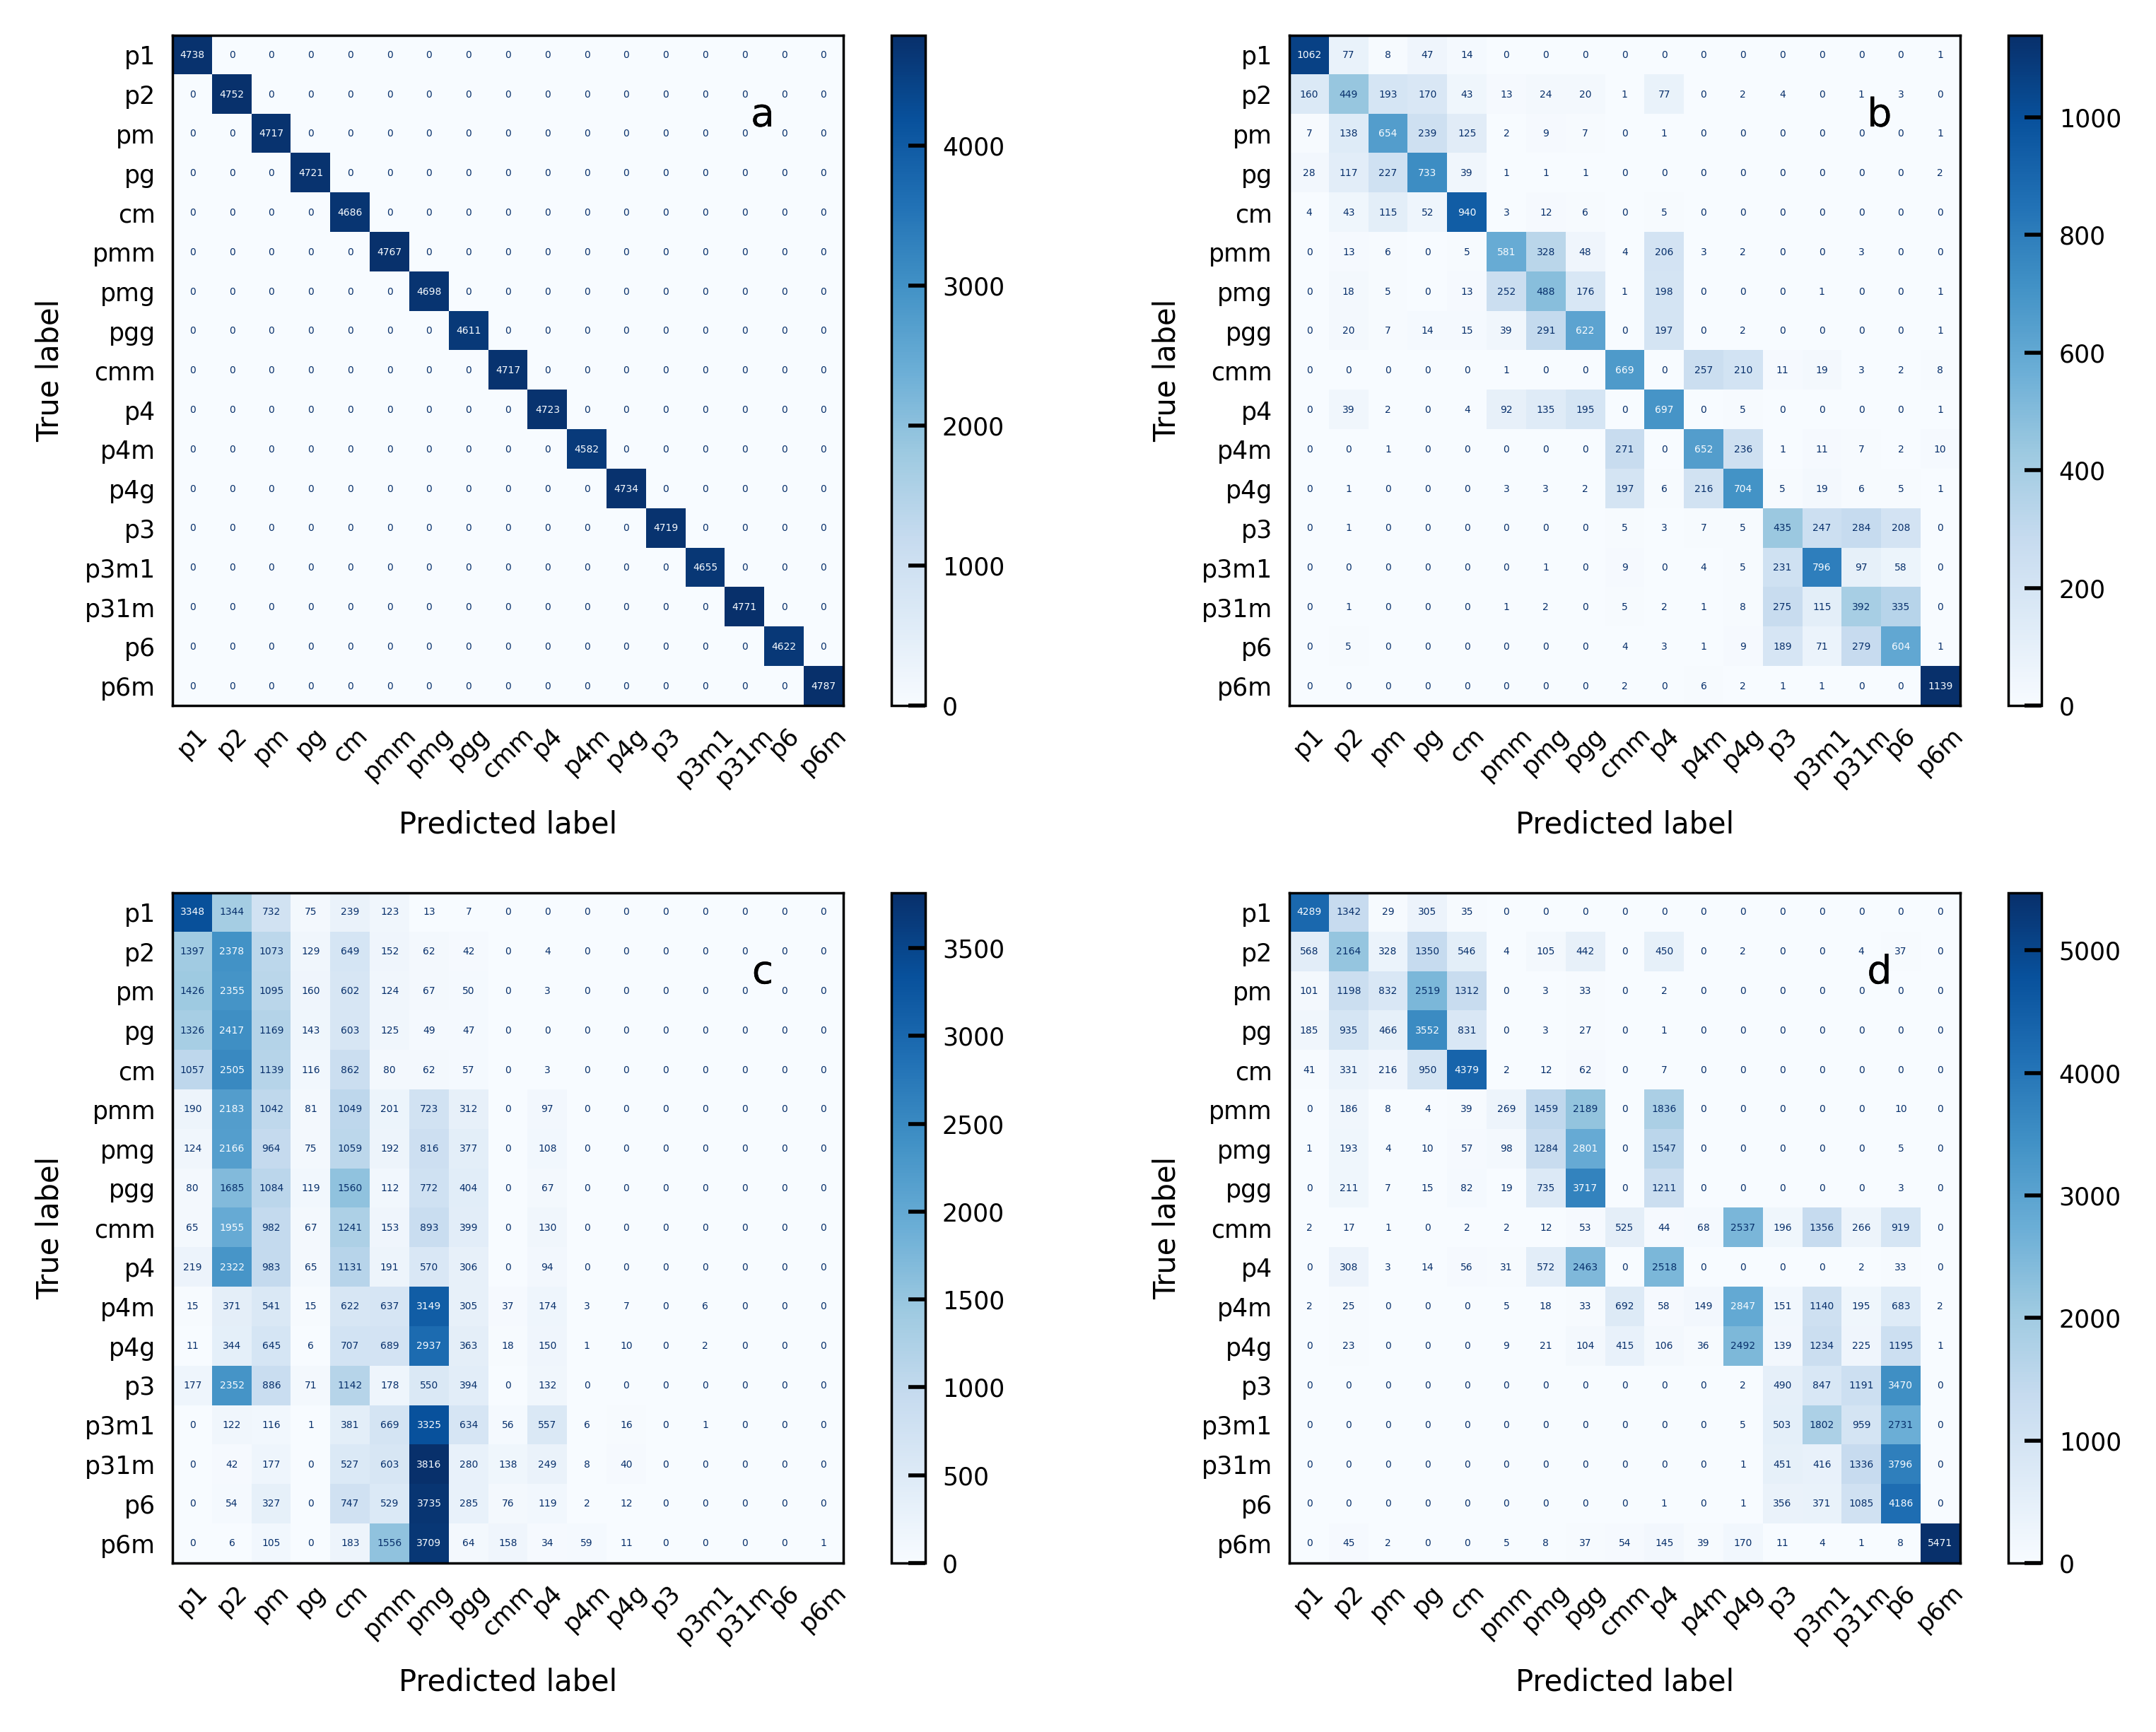

In [13]:
# sort files based on the logic order
order = ['train', 'valid', 'cv_atom', 'cv_noise']
def sort_key(file_path):
    for index, key in enumerate(order):
        if key in file_path:
            return index
    return len(order)
files = glob.glob(f'../../../saved_results/data_preprocessing/FFT_Radon_transform/*phase*')
sorted_files = sorted(files, key=sort_key)
print(sorted_files)

# extract the name
NAME = 'Summary_cm-' + '_'.join(os.path.basename(sorted_files[0]).split('-')[:2])
print(NAME)

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5))
for i, (ax, file) in enumerate(zip(axes.flatten(), sorted_files)):
    cm = np.load(file)
    plot_cm(cm, symmetry_classes, title=None, ax=ax, cm_style='simple', fig_style='printing', fig_index=i, font_size=2)
plt.tight_layout()
plt.savefig(f'../../../figures/data_preprocessing/FFT_Radon_transform/{NAME}.png')
plt.savefig(f'../../../figures/data_preprocessing/FFT_Radon_transform/{NAME}.svg')
plt.show()